1. Initialization table and python package

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../1_Data/Data_Clean/selling_books.csv")
df.head()

,Book,Author(s),Original language,First published,Approximate sales in millions,Genre
0,A Brief History of Time,Stephen Hawking,English,1988,25.0,POPULAR SCIENCE
1,A Message to Garcia,Elbert Hubbard,English,1899,40.0,ESSAY/LITERATURE
2,A Tale of Two Cities,Charles Dickens,English,1859,200.0,HISTORICAL FICTION
3,Adventures of Huckleberry Finn,Mark Twain,English,1885,20.0,"PICARESQUE NOVEL, BILDUNGSROMAN, SATIRE, ROBIN..."
4,Alcoholics Anonymous Big Book,Bill Wilson,English,1939,30.0,SELF-HELP


In [87]:
# check again if missing values are exist
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Book                           118 non-null    object 
 1   Author(s)                      118 non-null    object 
 2   Original language              118 non-null    object 
 3   First published                118 non-null    int64  
 4   Approximate sales in millions  118 non-null    float64
 5   Genre                          118 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 5.7+ KB


<b>What is the best or worst selling the books?</b>

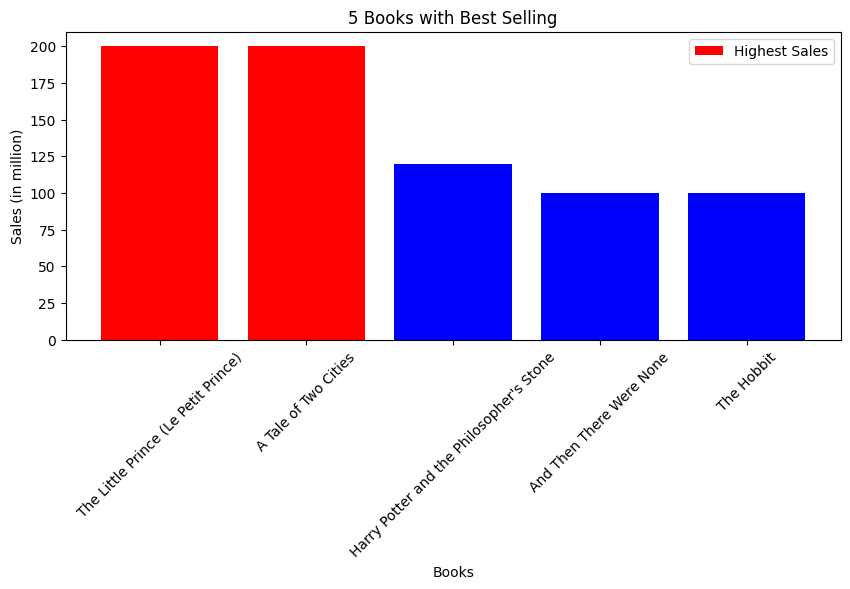

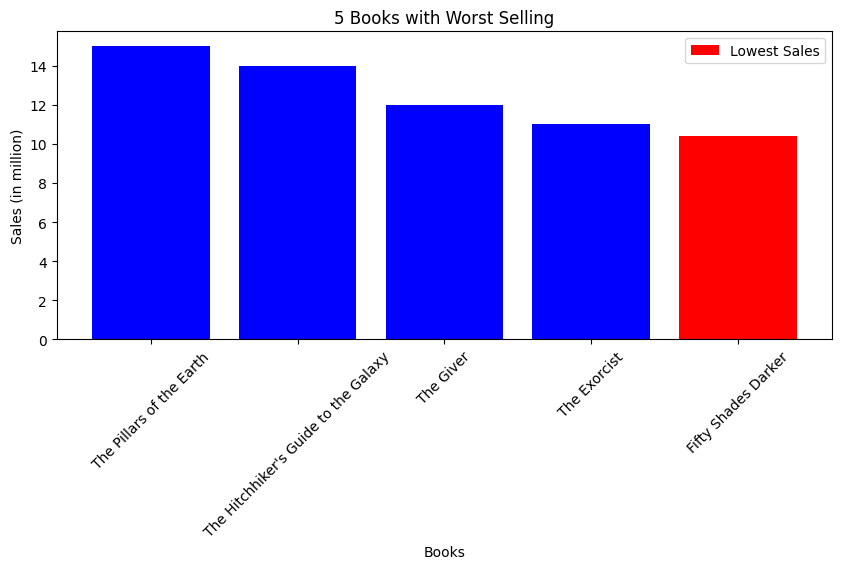

In [88]:
from matplotlib.patches import Patch
df_5BestSellBooks=df[["Book","Approximate sales in millions"]].sort_values(by=["Approximate sales in millions"],ascending=False).head(5)
df_5WorstSellBooks=df[["Book","Approximate sales in millions"]].sort_values(by=["Approximate sales in millions"],ascending=False).tail(5)
colors = ["red","red","blue","blue","blue"]
plt.figure(figsize=(10,4))
plt.bar(df_5BestSellBooks["Book"],df_5BestSellBooks["Approximate sales in millions"],color=colors,label="Highest Sales")
plt.xlabel("Books")
plt.ylabel("Sales (in million)")
plt.title("5 Books with Best Selling")
plt.tick_params(axis="x",labelsize = 10,labelrotation=45)
plt.legend()
plt.show()
plt.figure(figsize=(10,4))
plt.bar(df_5WorstSellBooks["Book"],df_5WorstSellBooks["Approximate sales in millions"],color=["blue","blue","blue","blue","red"],label="Lowest Sales")
plt.xlabel("Books")
plt.ylabel("Sales (in million)")
plt.tick_params(axis="x",labelsize = 10,labelrotation=45)
plt.title("5 Books with Worst Selling")
plt.legend(handles=[Patch(facecolor="red",label="Lowest Sales")])
plt.show()

<h2><b>Insight</b><br>
5 best books selling, you can see it above, but highest sales from them is "The Little Prince (Le Petite Prince)" and "A Tale Of Two Cities"<br>
5 worst books selling, you can see it above, but lowest sales from them is "Fifty Shades Darker"</h2>

<b>What most Genre of Book?</b>

In [89]:
df_genre = pd.DataFrame(df["Genre"].str.split(","))
df_genre = df_genre.explode("Genre",ignore_index=True)
df_genre = df_genre["Genre"].str.strip()
df_genre = pd.DataFrame(df_genre,columns=["Genre"])
df_genre.groupby("Genre").value_counts().sort_values(ascending=False)


Genre
FANTASY                       12
SELF-HELP                      9
NOVEL                          9
CHILDREN'S LITERATURE          9
HISTORICAL FICTION             6
                              ..
MANUAL                         1
NEW-AGE SPIRITUAL NOVEL        1
PARABLE                        1
PHILOSOPHICAL NOVEL            1
YOUNG ADULT ROMANTIC NOVEL     1
Name: count, Length: 88, dtype: int64

<h2><b>Insight</b><br>
Fantasy is one of most genre in this data, so we can conclude that author's books like to writen Fantasy book's genre </h2>

<b>The Author who has the most books</b>

In [90]:
df["Author(s)"].value_counts().sort_values(ascending=False)

Author(s)
J. K. Rowling       7
Roald Dahl          3
Suzanne Collins     3
Dan Brown           3
George Orwell       2
                   ..
Jiang Rong          1
Louise Hay          1
Beatrix Potter      1
William P. Young    1
Wayne Dyer          1
Name: count, Length: 104, dtype: int64

<h2><b>Insight</b><br>
throughout this data, J. K. Rowling is an author's who has written many books</h2>

<b>Correlation between year and Approximate sales books</b>

In [91]:
df_raw = pd.read_csv("../1_Data/Raw_Data/best-selling-books.csv").sort_values(["Book"])
df_raw

,Book,Author(s),Original language,First published,Approximate sales in millions,Genre
65,A Brief History of Time,Stephen Hawking,English,1988,25.0,Popular science
36,A Message to Garcia,Elbert Hubbard,English,1899,40.0,Essay/Literature
0,A Tale of Two Cities,Charles Dickens,English,1859,200.0,Historical fiction
129,A Wrinkle in Time,Madeleine L'Engle,English,1962,14.0,NaN
94,Adventures of Huckleberry Finn,Mark Twain,English,1885,20.0,"Picaresque novel, Bildungsroman, satire, Robin..."
...,...,...,...,...,...,...
64,Who Moved My Cheese?,Spencer Johnson,English,1998,29.0,"Self-help, motivational, business fable, psych..."
155,Wild Swans,Jung Chang,English,1992,10.0,NaN
88,Wolf Totem (狼图腾),Jiang Rong,Chinese,2004,20.0,Semi-autobiographical novel
20,You Can Heal Your Life,Louise Hay,English,1984,50.0,Self-help


In [92]:
import os
import time

path = "../1_Data/Raw_Data/best-selling-books.csv"

print(time.ctime(os.path.getmtime(path)))

Mon Oct 13 16:38:44 2025


In [93]:
df_time_sales = df_raw[["Book","First published","Approximate sales in millions"]]
# Because of this data updated in 2025, we can make new column as duration
df_time_sales["duration"] = 2025 - df_time_sales["First published"]
df_time_sales = df_time_sales.sort_values(by="duration",ascending=False)
df_time_sales["sales/year"] = df_time_sales["Approximate sales in millions"]/df_time_sales["duration"]
df_time_sales

C:\Users\User\AppData\Local\Temp\ipykernel_3740\3887625752.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time_sales["duration"] = 2025 - df_time_sales["First published"]


,Book,First published,Approximate sales in millions,duration,sales/year
140,The Divine Comedy (La Divina Commedia),1304,11.5,721,0.015950
66,Paul et Virginie,1788,25.0,237,0.105485
4,Dream of the Red Chamber (紅樓夢),1791,100.0,234,0.427350
96,Pride and Prejudice,1813,20.0,212,0.094340
0,A Tale of Two Cities,1859,200.0,166,1.204819
...,...,...,...,...,...
113,All the Light We Cannot See,2014,15.3,11,1.390909
73,The Girl on the Train,2015,23.0,10,2.300000
166,The Subtle Art of Not Giving a Fuck,2016,10.0,9,1.111111
106,Where the Crawdads Sing,2018,18.0,7,2.571429


In [94]:
corelation_app_dur = pd.DataFrame(np.corrcoef(df_time_sales["Approximate sales in millions"],df_time_sales["duration"]),index=["Approximate sales in millions","duration"],columns=["Approximate sales in millions","duration"])
corelation_app_dur


,Approximate sales in millions,duration
Approximate sales in millions,1.000000,0.124346
duration,0.124346,1.000000


<h2><b>Insight</b><br>
correlation between sales and duration book are positive correlation but a bit approch to zero, it means relations among two columns is not strong relation, the value around 12%</h2>

<b>Rates sales in 20th century based on Outlier data</b>

{'whiskers': [<matplotlib.lines.Line2D at 0x2b28feec880>,
 'caps': [<matplotlib.lines.Line2D at 0x2b28feed510>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b28feecc70>],
 'medians': [<matplotlib.lines.Line2D at 0x2b28feed990>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b28feef3a0>],
 'means': []}

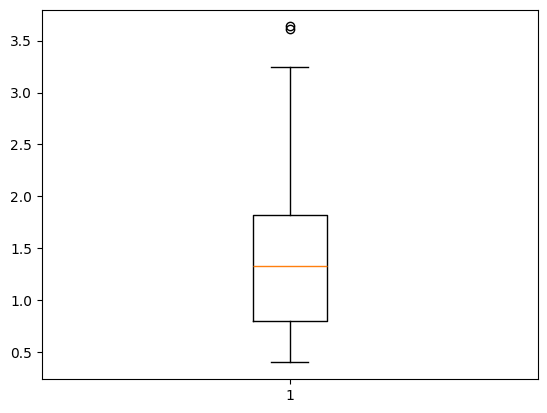

In [95]:
df_time_sales_20th = df_time_sales[df_time_sales["First published"]>=2000]
plt.boxplot(df_time_sales_20th["sales/year"])


In [96]:
threshold = 3.4
df_time_sales_20th[df_time_sales_20th["sales/year"]>=threshold]

,Book,First published,Approximate sales in millions,duration,sales/year
9,The Da Vinci Code,2003,80.0,22,3.636364
15,Harry Potter and the Deathly Hallows,2007,65.0,18,3.611111


<h2><b>Insight</b><br>
So, we conclude highest anomaly rate sales concist "The Da Vinci Code" and "Harry Potter and the Deathly Hallows", Classic books dominate cumulative sales because of time exposure.
However, when normalized by publication duration, modern franchises such as Harry Potter and The Da Vinci Code emerge as anomalously high-performing books.</h2>